In [ ]:
!git clone https://github.com/balbasty/nitorch.git
%cd nitorch
!pip install -e .
%cd ..


fatal: destination path 'nitorch' already exists and is not an empty directory.
/content/nitorch
Obtaining file:///content/nitorch
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for nitorch (pyproject.toml) ... done
  Created wheel for nitorch: filename=nitorch-0.1+470.g74b48d5-0.editable-py3-none-any.whl size=7617 sha256=2fed3885473921a7f45b1b8ed3cfeaf8f5a555781edf0040b7ef6b31319ac834
  Stored in directory: /tmp/pip-ephem-wheel-cache-ivs_tkxl/wheels/79/96/e4/d6577350b74d07aaf015bb1f9dad16fb9a61d71d5ddfbef1d6
Successfully built nitorch
  Attempting uninstall: nitorch
    Found existing installation: nitorch 0.1+470.g74b48d5
    Uninstalling nitorch-0.1+470.g74b48d5:
      Successfully uninstalled nitorch-0.1+470.g74b48d5
/content


In [ ]:
!git clone https://github.com/brudfors/UniRes.git
%cd UniRes
!pip install -e .


fatal: destination path 'UniRes' already exists and is not an empty directory.
/content/UniRes
Obtaining file:///content/UniRes
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/balbasty/nitorch to /tmp/pip-install-ivtdyrl7/nitorch_41ac3e9d09c2436593ac41de70ec78e5
  Running command git clone --filter=blob:none --quiet https://github.com/balbasty/nitorch /tmp/pip-install-ivtdyrl7/nitorch_41ac3e9d09c2436593ac41de70ec78e5
  Resolved https://github.com/balbasty/nitorch to commit 74b48d5b010d6d292fdbd2bb2af2e104d53bc2dd
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for nitorch: filename=nitorch-0.1+470.g74b48d5-py3-none-any.whl size=1050998 sha256=86dd6e9c68f3b97a10223224c1126f2b5ac9e695aefa0c05f97d138da1804c80
  Stored in directory: /tmp/pip-ephem-wheel-cache-ge7j9efp/wheels/54/78/9a/3bfdfda48d2b3548e859cff4643f77cd9fa91184418420bec2
Successfully built nitorch
  Atte

In [ ]:
from nitorch.plot import show_slices
from nitorch import io
import torch
import torch.nn.functional as F
import numpy as np
from unires._project import (_proj_apply, _proj_info)
from unires.struct import settings
from unires.run import preproc

torch.manual_seed(0)
np.random.seed(0)

In [ ]:
def mse(ref, pred):
    """
    Computes the MSE between a reference and a prediction.
    """
    return F.mse_loss(ref, pred, reduction='mean')

✅ File loaded successfully
Type: <class 'torch.Tensor'>
Shape: torch.Size([181, 217, 181])


[<Figure size 800x400 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object)]

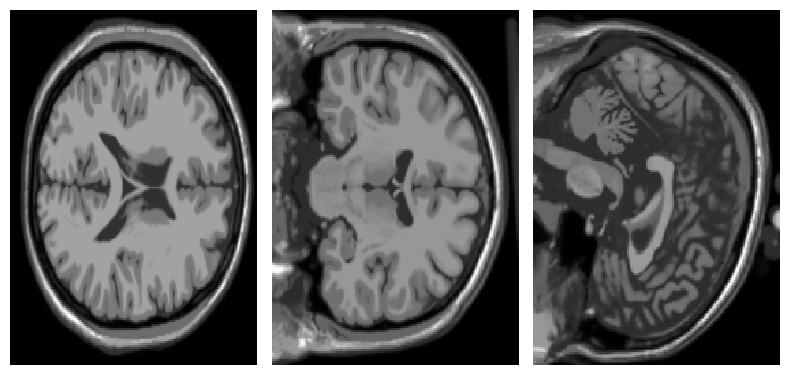

In [ ]:
import nibabel as nib
import numpy as np
import torch

# Path to your MRI inside UniRes
pth = "/content/UniRes/data/t1_icbm_normal_1mm_pn0_rf0.nii.gz"

# Load the NIfTI file
nii_y = io.map(pth)
y = nii_y.fdata()

# Check its shape and type
print("✅ File loaded successfully")
print("Type:", type(y))
print("Shape:", y.shape)

# Visualize 3 orthogonal slices (Axial, Coronal, Sagittal)
figsize = (8, 4)
show_slices(y, figsize=figsize)


In [ ]:
import os
import numpy as np
from PIL import Image
import torch

root = "/content/mri_esrgan_dataset"
hr_dir = os.path.join(root, "HR")
lr_dir = os.path.join(root, "LR")

os.makedirs(hr_dir, exist_ok=True)
os.makedirs(lr_dir, exist_ok=True)

def normalize_to_uint8(vol):
    v = vol.astype(np.float32)
    v -= v.min()
    if v.max() > 0:
        v /= v.max()
    v = (v * 255.0).clip(0, 255).astype(np.uint8)
    return v

def save_volume_slices(y, x, prefix):
    if isinstance(y, torch.Tensor):
        y = y.detach().cpu().numpy()
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()

    y = normalize_to_uint8(y)
    x = normalize_to_uint8(x)

    D = y.shape[0]

    for i in range(D):
        hr_slice = y[i]
        lr_slice = x[i]

        hr_img = Image.fromarray(hr_slice)
        lr_img = Image.fromarray(lr_slice)

        filename = f"{prefix}_slice_{i:03d}.png"

        hr_img.save(os.path.join(hr_dir, filename))
        lr_img.save(os.path.join(lr_dir, filename))

    print(f"{prefix}: saved {D} slices")

cuda
dim_y=tensor([181., 217., 181.], dtype=torch.float64)
dim_x=tensor([181., 217.,  45.], dtype=torch.float64)
T1: saved 181 slices


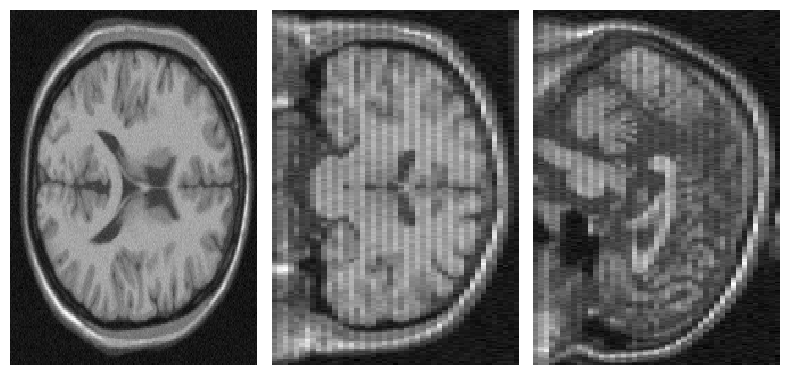

In [ ]:
# Apply UniRes forward model to BrainWeb MRI (y = Ax + n)

# Parameters
# https://github.com/brudfors/UniRes/blob/master/unires/struct.py#L57
vx_scl = torch.tensor((1, 1, 4))  # scaling of the voxel sizes to create the low-res image
prof_ip = 0  # (0=rect|1=tri|2=gauss)
prof_tp = 0  # (0=rect|1=tri|2=gauss)
s_gap = 0.0  # slice gap
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)  # GPU or CPU
eo_scl = 0.1  # even/odd slice scaling
rigid = torch.eye(4)  # rigid transformation
std_noise = 30 # std of Gaussian noise

# Set output field of view
mat_y = nii_y.affine
dim_y = torch.as_tensor(y.shape, dtype=mat_y.dtype)
scl = torch.as_tensor(torch.cat((vx_scl, torch.ones(1))), dtype=mat_y.dtype)
mat_scl = torch.diag(scl)
mat_x = mat_y.mm(mat_scl)
dim_x = mat_scl[:3, :3].inverse().mm(dim_y[:, None]).floor().squeeze()
print(f"dim_y={dim_y}")
print(f"dim_x={dim_x}")

# Set device
mat_x = mat_x.to(device)
mat_y = mat_y.to(device)
dim_y = dim_y.to(device)
dim_x = dim_x.to(device)
y = y.to(device)

# Create projection operator
po = _proj_info(
    dim_y, mat_y, dim_x, mat_x,
    rigid=rigid, prof_ip=prof_ip, prof_tp=prof_tp,
    gap=s_gap, device=device, scl=eo_scl
)
A = lambda y: _proj_apply("A", y[None, None, ...], po)[0, 0, ...]
n = std_noise*torch.randn(dim_x.cpu().type(torch.int).tolist(), device=device)

# Apply forward model A
x = A(y) + n

# Save HR/LR slices for ESRGAN training
save_volume_slices(y, x, "T1")

# Visualise results
fig = show_slices(x, figsize=figsize)

**MRI Slice Preparation**
Converted 3D MRI volumes into 2D slices,
Normalized intensity values,
Saved paired:
HR slices (original)
LR slices (degraded),
Created training dataset for ESRGAN

In [ ]:
import os
import numpy as np
from PIL import Image

root = "/content/mri_esrgan_dataset"
hr_dir = os.path.join(root, "HR")
lr_dir = os.path.join(root, "LR")

os.makedirs(hr_dir, exist_ok=True)
os.makedirs(lr_dir, exist_ok=True)

def normalize_to_uint8(vol):
    v = vol.astype(np.float32)
    v -= v.min()
    if v.max() > 0:
        v /= v.max()
    v = (v * 255.0).clip(0, 255).astype(np.uint8)
    return v

def save_volume_slices(y, x, prefix):
    """
    y: HR volume (torch tensor or numpy)
    x: LR volume (torch tensor or numpy)
    prefix: string like 'T1', 'T2', 'PD'
    """

    # Convert to numpy if needed
    if isinstance(y, torch.Tensor):
        y = y.detach().cpu().numpy()
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()

    y = normalize_to_uint8(y)
    x = normalize_to_uint8(x)

    D = y.shape[0]

    for i in range(D):
        hr_slice = y[i]
        lr_slice = x[i]

        hr_img = Image.fromarray(hr_slice)
        lr_img = Image.fromarray(lr_slice)

        filename = f"{prefix}_slice_{i:03d}.png"

        hr_img.save(os.path.join(hr_dir, filename))
        lr_img.save(os.path.join(lr_dir, filename))

    print(f"{prefix}: saved {D} slices")

**ESRGAN Generator: RRDBNet**
Takes degraded MRI slice as input,
Uses convolution layers to extract features,
Uses Residual Dense Blocks to preserve and combine information,
Uses RRDB blocks to learn complex anatomical structures,
Outputs a reconstructed super-resolved MRI slice.


In [ ]:
import torch
import torch.nn as nn

class ResidualDenseBlock_5C(nn.Module):
    def __init__(self, nf=64, gc=32):
        super().__init__()
        self.conv1 = nn.Conv2d(nf, gc, 3, 1, 1)
        self.conv2 = nn.Conv2d(nf + gc, gc, 3, 1, 1)
        self.conv3 = nn.Conv2d(nf + 2 * gc, gc, 3, 1, 1)
        self.conv4 = nn.Conv2d(nf + 3 * gc, gc, 3, 1, 1)
        self.conv5 = nn.Conv2d(nf + 4 * gc, nf, 3, 1, 1)
        self.lrelu = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.lrelu(self.conv2(torch.cat((x, x1), 1)))
        x3 = self.lrelu(self.conv3(torch.cat((x, x1, x2), 1)))
        x4 = self.lrelu(self.conv4(torch.cat((x, x1, x2, x3), 1)))
        x5 = self.conv5(torch.cat((x, x1, x2, x3, x4), 1))
        return x5 * 0.2 + x


class RRDB(nn.Module):
    def __init__(self, nf, gc=32):
        super().__init__()
        self.rdb1 = ResidualDenseBlock_5C(nf, gc)
        self.rdb2 = ResidualDenseBlock_5C(nf, gc)
        self.rdb3 = ResidualDenseBlock_5C(nf, gc)

    def forward(self, x):
        out = self.rdb1(x)
        out = self.rdb2(out)
        out = self.rdb3(out)
        return out * 0.2 + x


class RRDBNet(nn.Module):
    def __init__(self, in_nc=1, out_nc=1, nf=64, nb=8, gc=32, scale=1):
        super().__init__()
        self.scale = scale
        self.conv_first = nn.Conv2d(in_nc, nf, 3, 1, 1)

        self.RRDB_trunk = nn.Sequential(*[RRDB(nf, gc) for _ in range(nb)])
        self.trunk_conv = nn.Conv2d(nf, nf, 3, 1, 1)

        up_layers = []
        if scale in [2, 4]:
            for _ in range(int(scale // 2)):
                up_layers += [
                    nn.Conv2d(nf, nf * 4, 3, 1, 1),
                    nn.PixelShuffle(2),
                    nn.LeakyReLU(0.2, inplace=True),
                ]
        self.upconv = nn.Sequential(*up_layers)

        self.hr_conv = nn.Conv2d(nf, nf, 3, 1, 1)
        self.conv_last = nn.Conv2d(nf, out_nc, 3, 1, 1)
        self.lrelu = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        fea = self.conv_first(x)
        trunk = self.trunk_conv(self.RRDB_trunk(fea))
        fea = fea + trunk

        if self.scale > 1:
            fea = self.upconv(fea)

        out = self.lrelu(self.hr_conv(fea))
        out = self.conv_last(out)
        return out

**MRI Dataset Preparation for ESRGAN**
Loaded paired HR/LR MRI slices,
Matched corresponding slices,
Resized LR images,
Applied random patch extraction (64×64),
Applied data augmentation,
Created batches for ESRGAN training.

In [ ]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import glob
import random
import os
import numpy as np
import torch

class MRIPairedDataset(Dataset):
    def __init__(self, hr_dir, lr_dir, patch_size=64, augment=True):
        self.hr_paths = sorted(glob.glob(os.path.join(hr_dir, "*.png")))
        self.lr_paths = sorted(glob.glob(os.path.join(lr_dir, "*.png")))

        assert len(self.hr_paths) == len(self.lr_paths), "HR and LR image counts do not match"

        # Extra check: filenames should match
        hr_names = [os.path.basename(p) for p in self.hr_paths]
        lr_names = [os.path.basename(p) for p in self.lr_paths]
        assert hr_names == lr_names, "HR and LR filenames do not match"

        self.patch_size = patch_size
        self.augment = augment

    def __len__(self):
        return len(self.hr_paths)

    def __getitem__(self, idx):
        hr = Image.open(self.hr_paths[idx]).convert("L")
        lr = Image.open(self.lr_paths[idx]).convert("L")

        # Force LR to same size as HR
        lr = lr.resize(hr.size, Image.BICUBIC)

        hr = np.array(hr, dtype=np.float32) / 255.0
        lr = np.array(lr, dtype=np.float32) / 255.0

        h, w = hr.shape
        ps = self.patch_size

        if h >= ps and w >= ps:
            top = random.randint(0, h - ps)
            left = random.randint(0, w - ps)

            hr = hr[top:top+ps, left:left+ps].copy()
            lr = lr[top:top+ps, left:left+ps].copy()
        else:
            hr = hr.copy()
            lr = lr.copy()

        if self.augment:
            if random.random() < 0.5:
                hr = np.fliplr(hr).copy()
                lr = np.fliplr(lr).copy()

            if random.random() < 0.5:
                hr = np.flipud(hr).copy()
                lr = np.flipud(lr).copy()

        hr = torch.tensor(hr, dtype=torch.float32).unsqueeze(0)
        lr = torch.tensor(lr, dtype=torch.float32).unsqueeze(0)

        return lr, hr


patch_size = 64

train_dataset = MRIPairedDataset(
    hr_dir,
    lr_dir,
    patch_size=patch_size,
    augment=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

print("Num slices:", len(train_dataset))
print("Patch size:", patch_size)

Num slices: 181
Patch size: 64


In [ ]:
lr, hr = train_dataset[0]
print("Single sample:", lr.shape, hr.shape, lr.dtype, hr.dtype)

Single sample: torch.Size([1, 64, 64]) torch.Size([1, 64, 64]) torch.float32 torch.float32


In [ ]:
for lr, hr in train_loader:
    print("Batch:", lr.shape, hr.shape)
    break

Batch: torch.Size([4, 1, 64, 64]) torch.Size([4, 1, 64, 64])


**ESRGAN Discriminator**:
Receives real HR MRI and fake SR MRI,
Learns to distinguish real vs fake images,
Uses convolution layers to extract features,
Forces generator to create more realistic MRI reconstructions,

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, in_nc=1, base_nf=64):
        super().__init__()
        def block(in_f, out_f, stride=1, bn=True):
            layers = [nn.Conv2d(in_f, out_f, 3, stride, 1)]
            if bn:
                layers.append(nn.BatchNorm2d(out_f))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return nn.Sequential(*layers)

        self.model = nn.Sequential(
            block(in_nc, base_nf, stride=1, bn=False),
            block(base_nf, base_nf, stride=2),
            block(base_nf, base_nf*2, stride=1),
            block(base_nf*2, base_nf*2, stride=2),
            block(base_nf*2, base_nf*4, stride=1),
            block(base_nf*4, base_nf*4, stride=2),
            block(base_nf*4, base_nf*8, stride=1),
            block(base_nf*8, base_nf*8, stride=2),
        )

        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(base_nf*8, 100),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(100, 1)
        )

    def forward(self, x):
        feat = self.model(x)
        out = self.fc(feat)
        return out

In [ ]:
print(RRDBNet)
print(Discriminator)

<class '__main__.RRDBNet'>
<class '__main__.Discriminator'>


**Perceptual Loss**:
Uses pre-trained VGG19 feature extractor,
Compares high-level features instead of raw pixels,
Improves sharpness and anatomical structure,
Produces visually better MRI reconstructions,

Tradeoff:
slightly worse MSE/PSNR but better visual quality.

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

class VGGPerceptualLoss(nn.Module):
    def __init__(self, resize=False):
        super().__init__()
        vgg = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features
        self.feature_extractor = nn.Sequential(*list(vgg[:35])).eval()  # up to conv5_4-ish
        for param in self.feature_extractor.parameters():
            param.requires_grad = False

        self.resize = resize

        # ImageNet normalization
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        self.std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

    def forward(self, x, y):
        """
        x, y: tensors of shape (B,1,H,W) in [0,1]
        """
        # Convert grayscale MRI to 3-channel
        x = x.repeat(1, 3, 1, 1)
        y = y.repeat(1, 3, 1, 1)

        mean = self.mean.to(x.device)
        std = self.std.to(x.device)

        x = (x - mean) / std
        y = (y - mean) / std

        fx = self.feature_extractor(x)
        fy = self.feature_extractor(y)

        return nn.functional.l1_loss(fx, fy)

This code trains ESRGAN to reconstruct high-resolution MRI slices from degraded low-resolution inputs by first pretraining the generator with pixel loss, then fine-tuning it with GAN and perceptual losses for sharper and more realistic results.

In [ ]:
import torch
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Models
G = RRDBNet(in_nc=1, out_nc=1, nf=64, nb=8, gc=32, scale=1).to(device)
D = Discriminator(in_nc=1, base_nf=64).to(device)

# Losses
criterion_pixel = nn.L1Loss().to(device)
criterion_gan = nn.BCEWithLogitsLoss().to(device)
criterion_perceptual = VGGPerceptualLoss().to(device)

# =========================
# 1) PRETRAIN GENERATOR
# =========================
pretrain_epochs = 50
optim_G = torch.optim.Adam(G.parameters(), lr=1e-4, betas=(0.9, 0.999))

print("\nStarting generator pretraining...\n")

for epoch in range(pretrain_epochs):
    G.train()
    running_loss = 0.0

    for lr, hr in train_loader:
        lr = lr.to(device)
        hr = hr.to(device)

        optim_G.zero_grad()

        fake_hr = G(lr)
        loss = criterion_pixel(fake_hr, hr)

        loss.backward()
        optim_G.step()

        running_loss += loss.item()

    print(f"Pretrain Epoch [{epoch+1}/{pretrain_epochs}] "
          f"L1 Loss: {running_loss / len(train_loader):.4f}")

    # Save checkpoint
    torch.save(G.state_dict(), "/content/G_pretrain_latest.pth")
    if (epoch + 1) % 10 == 0:
        torch.save(G.state_dict(), f"/content/G_pretrain_epoch_{epoch+1}.pth")

# =========================
# 2) GAN FINE-TUNING
# =========================
gan_epochs = 200
optim_G = torch.optim.Adam(G.parameters(), lr=1e-4, betas=(0.9, 0.999))
optim_D = torch.optim.Adam(D.parameters(), lr=1e-4, betas=(0.9, 0.999))

lambda_pixel = 1.0
lambda_gan = 5e-3
lambda_perceptual = 5e-2

print("\nStarting GAN fine-tuning...\n")

for epoch in range(gan_epochs):
    G.train()
    D.train()

    running_g_loss = 0.0
    running_d_loss = 0.0
    running_l1_loss = 0.0
    running_perceptual_loss = 0.0
    running_gan_loss = 0.0

    for lr, hr in train_loader:
        lr = lr.to(device)
        hr = hr.to(device)

        # ------------------
        # Train Discriminator
        # ------------------
        optim_D.zero_grad()

        with torch.no_grad():
            fake_hr = G(lr)

        pred_real = D(hr)
        pred_fake = D(fake_hr.detach())

        real_labels = torch.ones_like(pred_real)
        fake_labels = torch.zeros_like(pred_fake)

        d_loss_real = criterion_gan(pred_real, real_labels)
        d_loss_fake = criterion_gan(pred_fake, fake_labels)
        d_loss = 0.5 * (d_loss_real + d_loss_fake)

        d_loss.backward()
        optim_D.step()

        # ------------------
        # Train Generator
        # ------------------
        optim_G.zero_grad()

        fake_hr = G(lr)
        pred_fake_for_G = D(fake_hr)
        l_content = criterion_pixel(fake_hr, hr)
        l_perceptual = criterion_perceptual(fake_hr, hr)
        g_gan_loss = criterion_gan(pred_fake_for_G, real_labels)

        g_loss = (
            lambda_pixel * l_content
            + lambda_perceptual * l_perceptual
            + lambda_gan * g_gan_loss
        )



        g_loss.backward()
        optim_G.step()

        running_g_loss += g_loss.item()
        running_d_loss += d_loss.item()
        running_l1_loss += l_content.item()
        running_perceptual_loss += l_perceptual.item()
        running_gan_loss += g_gan_loss.item()

    print(
        f"GAN Epoch [{epoch+1}/{gan_epochs}] "
        f"G_loss: {running_g_loss/len(train_loader):.4f} | "
        f"D_loss: {running_d_loss/len(train_loader):.4f} | "
        f"L1: {running_l1_loss/len(train_loader):.4f} | "
        f"Perc: {running_perceptual_loss/len(train_loader):.4f} | "
        f"GAN: {running_gan_loss/len(train_loader):.4f}"
    )

    # Save checkpoint
    torch.save(G.state_dict(), "/content/G_latest.pth")
    torch.save(D.state_dict(), "/content/D_latest.pth")

    if (epoch + 1) % 10 == 0:
        torch.save(G.state_dict(), f"/content/G_epoch_{epoch+1}.pth")
        torch.save(D.state_dict(), f"/content/D_epoch_{epoch+1}.pth")

Device: cuda
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:04<00:00, 135MB/s]



Starting generator pretraining...

Pretrain Epoch [1/50] L1 Loss: 0.0877
Pretrain Epoch [2/50] L1 Loss: 0.0492
Pretrain Epoch [3/50] L1 Loss: 0.0457
Pretrain Epoch [4/50] L1 Loss: 0.0435
Pretrain Epoch [5/50] L1 Loss: 0.0452
Pretrain Epoch [6/50] L1 Loss: 0.0421
Pretrain Epoch [7/50] L1 Loss: 0.0450
Pretrain Epoch [8/50] L1 Loss: 0.0428
Pretrain Epoch [9/50] L1 Loss: 0.0418
Pretrain Epoch [10/50] L1 Loss: 0.0402
Pretrain Epoch [11/50] L1 Loss: 0.0412
Pretrain Epoch [12/50] L1 Loss: 0.0408
Pretrain Epoch [13/50] L1 Loss: 0.0399
Pretrain Epoch [14/50] L1 Loss: 0.0415
Pretrain Epoch [15/50] L1 Loss: 0.0404
Pretrain Epoch [16/50] L1 Loss: 0.0402
Pretrain Epoch [17/50] L1 Loss: 0.0398
Pretrain Epoch [18/50] L1 Loss: 0.0400
Pretrain Epoch [19/50] L1 Loss: 0.0383
Pretrain Epoch [20/50] L1 Loss: 0.0415
Pretrain Epoch [21/50] L1 Loss: 0.0436
Pretrain Epoch [22/50] L1 Loss: 0.0387
Pretrain Epoch [23/50] L1 Loss: 0.0381
Pretrain Epoch [24/50] L1 Loss: 0.0401
Pretrain Epoch [25/50] L1 Loss: 0.040

**Full MRI Reconstruction**
Loaded all degraded MRI slices,
Applied trained ESRGAN generator,
Reconstructed each slice,
Combined slices back into full 3D MRI volume,

Output:

LR MRI volume,
SR MRI volume,
HR MRI volume,

In [ ]:
import os
import glob
import numpy as np
from PIL import Image
import torch

G.eval()

lr_paths = sorted(glob.glob(os.path.join(lr_dir, "*.png")))
hr_paths = sorted(glob.glob(os.path.join(hr_dir, "*.png")))

sr_slices = []
lr_slices = []
hr_slices = []

for lr_path, hr_path in zip(lr_paths, hr_paths):
    img_lr = Image.open(lr_path).convert("L")
    img_hr = Image.open(hr_path).convert("L")

    # Resize LR to HR size exactly like training
    img_lr_resized = img_lr.resize(img_hr.size, Image.BICUBIC)

    lr_arr = np.array(img_lr_resized, dtype=np.float32) / 255.0
    hr_arr = np.array(img_hr, dtype=np.float32) / 255.0

    tensor_lr = torch.from_numpy(lr_arr).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        sr = G(tensor_lr).cpu().squeeze().numpy()

    sr = np.clip(sr, 0, 1)

    lr_slices.append(lr_arr)
    sr_slices.append(sr)
    hr_slices.append(hr_arr)

lr_volume = np.stack(lr_slices, axis=0)
sr_volume = np.stack(sr_slices, axis=0)
hr_volume = np.stack(hr_slices, axis=0)

print("LR volume shape:", lr_volume.shape)
print("SR volume shape:", sr_volume.shape)
print("HR volume shape:", hr_volume.shape)

LR volume shape: (181, 217, 181)
SR volume shape: (181, 217, 181)
HR volume shape: (181, 217, 181)


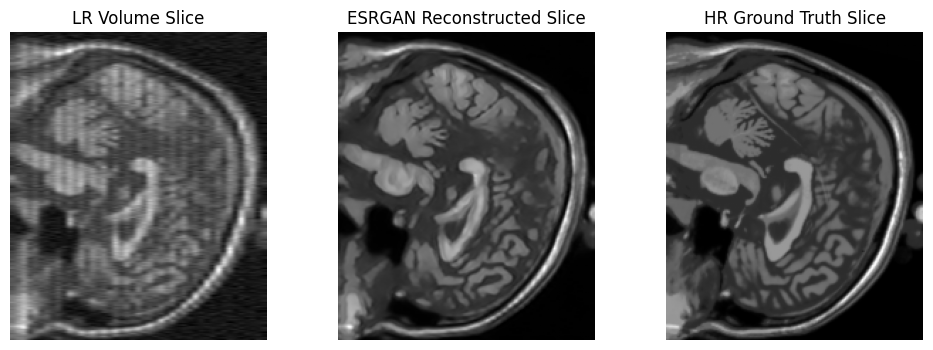

In [ ]:
mid = lr_volume.shape[0] // 2

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("LR Volume Slice")
plt.imshow(lr_volume[mid], cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("ESRGAN Reconstructed Slice")
plt.imshow(sr_volume[mid], cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("HR Ground Truth Slice")
plt.imshow(hr_volume[mid], cmap="gray")
plt.axis("off")

plt.show()

In [ ]:
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import numpy as np

mse_all = np.mean((sr_volume - hr_volume) ** 2)
psnr_all = peak_signal_noise_ratio(hr_volume, sr_volume, data_range=1.0)

ssim_vals = []
for i in range(sr_volume.shape[0]):
    ssim_vals.append(structural_similarity(hr_volume[i], sr_volume[i], data_range=1.0))

ssim_all = np.mean(ssim_vals)

print("Whole-volume MSE :", mse_all)
print("Whole-volume PSNR:", psnr_all)
print("Whole-volume SSIM:", ssim_all)

Whole-volume MSE : 0.003168821
Whole-volume PSNR: 24.991023928574823
Whole-volume SSIM: 0.7771730920080803
